**DATA LOADING**

Using dataset path: /kaggle/input/cifar10-python
Top-level files/folders:
 - cifar-10-batches-py
 - cifar-10-python.tar.gz

Looking for: /kaggle/input/cifar10-python/cifar-10-batches-py/batches.meta
 and  /kaggle/input/cifar10-python/cifar-10-batches-py/data_batch_1

CIFAR-10 class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Keys in data_batch_1: ['batch_label', 'labels', 'data', 'filenames']
data shape: (10000, 3072)
labels length: 10000

Label counts (data_batch_1):
   label_id  count  label_name
0         0   1005    airplane
1         1    974  automobile
2         2   1032        bird
3         3   1016         cat
4         4    999        deer
5         5    937         dog
6         6   1030        frog
7         7   1001       horse
8         8   1025        ship
9         9    981       truck


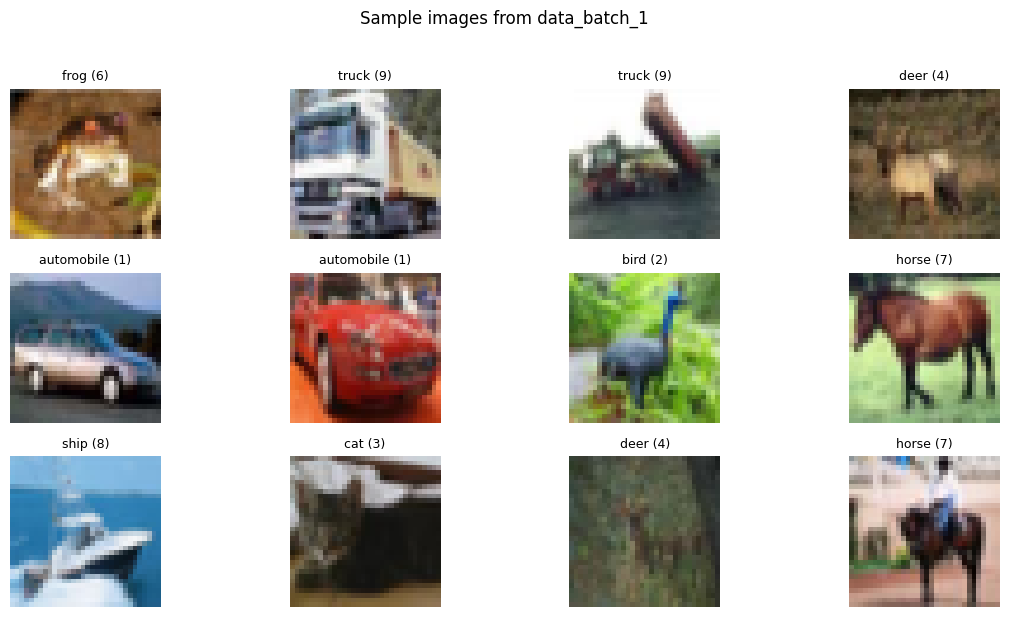


Summary:
 - dataset_dir: /kaggle/input/cifar10-python/cifar-10-batches-py
 - batch samples per file (expected): 10000
 - image shape: (32, 32, 3)
 - num_classes: 10


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# =====================================================
#  Load data from local train_images/ and test_images/
# =====================================================

# Define paths
TRAIN_IMAGES_DIR = "./train_images"
TEST_IMAGES_DIR = "./test_images"
TRAIN_LABELS_CSV = "./train_labels.csv"

# Verify directories exist
print("Checking directories...")
print(f"Train images directory exists: {os.path.exists(TRAIN_IMAGES_DIR)}")
print(f"Test images directory exists: {os.path.exists(TEST_IMAGES_DIR)}")
print(f"Train labels CSV exists: {os.path.exists(TRAIN_LABELS_CSV)}")

# Load training labels
print("\nLoading training labels...")
train_df = pd.read_csv(TRAIN_LABELS_CSV)
print("Train data shape:", train_df.shape)
print("Train data columns:", train_df.columns.tolist())
print("\nFirst few rows:")
print(train_df.head(10))

# Get unique class labels
class_names = sorted(train_df['label'].unique())
print(f"\nClass names ({len(class_names)}): {class_names}")

# Create label mapping
label2idx = {name: idx for idx, name in enumerate(class_names)}
idx2label = {idx: name for name, idx in label2idx.items()}
print("\nLabel to index mapping:", label2idx)

# Add label indices to dataframe
train_df['label_idx'] = train_df['label'].map(label2idx)

# Count samples per class
print("\nTraining samples per class:")
print(train_df['label'].value_counts().sort_index())

# List test images
print(f"\nTest images available: {len(os.listdir(TEST_IMAGES_DIR))} files")
test_images = sorted([f for f in os.listdir(TEST_IMAGES_DIR) if f.endswith('.png')])
print(f"Sample test image names: {test_images[:5]}")

# Display sample training images
print("\nDisplaying sample training images...")
sample_indices = np.random.choice(len(train_df), 12, replace=False)
plt.figure(figsize=(12, 6))

for i, idx in enumerate(sample_indices):
    row = train_df.iloc[idx]
    img_path = os.path.join(TRAIN_IMAGES_DIR, f"{row['id']}.png")
    
    if os.path.exists(img_path):
        img = Image.open(img_path)
        ax = plt.subplot(3, 4, i + 1)
        ax.imshow(img)
        ax.set_title(f"{row['label']} ({row['label_idx']})", fontsize=9)
        ax.axis('off')

plt.suptitle("Sample Training Images", y=1.02)
plt.tight_layout()
plt.show()

print("\nData loading complete!")


**DATA PREPROCESSING**

Loading: /kaggle/input/cifar10-python/cifar-10-batches-py/data_batch_1
Loading: /kaggle/input/cifar10-python/cifar-10-batches-py/data_batch_2
Loading: /kaggle/input/cifar10-python/cifar-10-batches-py/data_batch_3
Loading: /kaggle/input/cifar10-python/cifar-10-batches-py/data_batch_4
Loading: /kaggle/input/cifar10-python/cifar-10-batches-py/data_batch_5

Shapes:
 X_train: (50000, 32, 32, 3) float32
 y_train: (50000,) int64
 X_test : (10000, 32, 32, 3) float32
 y_test : (10000,) int64


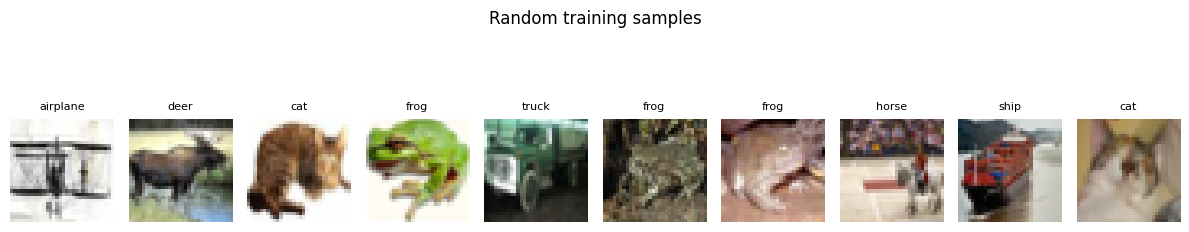


Saved: /kaggle/working/X_train.npy, y_train.npy, X_test.npy, y_test.npy


In [ ]:
# =====================================================
#  Load images from local train_images/ and test_images/
# =====================================================
import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Define paths
TRAIN_IMAGES_DIR = "./train_images"
TEST_IMAGES_DIR = "./test_images"
TRAIN_LABELS_CSV = "./train_labels.csv"

# Load training labels and map to image paths
train_df = pd.read_csv(TRAIN_LABELS_CSV, dtype={'id': str})
label2idx = {name: idx for idx, name in enumerate(sorted(train_df['label'].unique()))}
train_df['label_idx'] = train_df['label'].map(label2idx)

# Load all training images into memory (or reference them)
print("Loading training images...")
train_images_list = []
train_labels_list = []

for idx, row in train_df.iterrows():
    img_path = os.path.join(TRAIN_IMAGES_DIR, f"{row['id']}.png")
    if os.path.exists(img_path):
        img = Image.open(img_path).convert('RGB')
        img_array = np.array(img, dtype=np.float32) / 255.0
        train_images_list.append(img_array)
        train_labels_list.append(int(row['label_idx']))

X_train = np.array(train_images_list)
y_train = np.array(train_labels_list, dtype=np.int64)

print(f"Training data shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Data type: {X_train.dtype}, Label type: {y_train.dtype}")

# Load all test images
print("\nLoading test images...")
test_images_list = []
test_ids = []

test_files = sorted([f for f in os.listdir(TEST_IMAGES_DIR) if f.endswith('.png')])
for fname in test_files:
    img_path = os.path.join(TEST_IMAGES_DIR, fname)
    img = Image.open(img_path).convert('RGB')
    img_array = np.array(img, dtype=np.float32) / 255.0
    test_images_list.append(img_array)
    test_ids.append(fname.replace('.png', ''))

X_test = np.array(test_images_list)
test_ids = np.array(test_ids)

print(f"Test data shape: {X_test.shape}")
print(f"Test IDs shape: {test_ids.shape}")

# Show sample images
print("\nDisplaying sample test images...")
sample_indices = np.random.choice(len(X_test), 10, replace=False)
plt.figure(figsize=(12, 3))

for i, idx in enumerate(sample_indices):
    ax = plt.subplot(1, 10, i + 1)
    ax.imshow((X_test[idx] * 255).astype('uint8'))
    ax.set_title(test_ids[idx], fontsize=8)
    ax.axis('off')

plt.suptitle("Random test samples")
plt.tight_layout()
plt.show()

# Label statistics
print("\nLabel distribution in training set:")
unique, counts = np.unique(y_train, return_counts=True)
idx2label = {idx: name for name, idx in label2idx.items()}
for u, c in zip(unique, counts):
    print(f"  {idx2label[u]}: {c}")

print("\nData preprocessing complete!")


**Vision Transformer (ViT)**

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from sklearn.model_selection import train_test_split
import os
import pandas as pd
import numpy as np
from PIL import Image

# =====================================================
#  Custom Dataset Class for Local Images
# =====================================================
class LocalImageDataset(Dataset):
    def __init__(self, image_ids, image_paths, labels=None, transform=None, image_dir=None):
        """
        Args:
            image_ids: list of image IDs (filenames without extension)
            image_paths: list of full paths to images OR None if using image_dir
            labels: list of labels (None for test set without labels)
            transform: torchvision transforms
            image_dir: directory containing images (used if image_paths is None)
        """
        self.image_ids = image_ids
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        self.image_dir = image_dir

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        
        # Load image
        if self.image_paths is not None:
            img_path = self.image_paths[idx]
        else:
            img_path = os.path.join(self.image_dir, f"{img_id}.png")
        
        img = Image.open(img_path).convert('RGB')
        
        # Apply transforms
        if self.transform:
            img = self.transform(img)
        
        # Return image and label (or just image if no labels)
        if self.labels is not None:
            label = self.labels[idx]
            return img, label
        else:
            return img, img_id


# ======================
#  Define Transformations
# ======================
cifar_mean = (0.4914, 0.4822, 0.4465)
cifar_std  = (0.2470, 0.2435, 0.2616)

train_transform = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.ToTensor(),
    T.Normalize(cifar_mean, cifar_std),
    T.RandomErasing(p=0.5, scale=(0.02, 0.2), ratio=(0.3, 3.3))
])

test_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(cifar_mean, cifar_std),
])


# =====================================
#  Create Datasets from Local Folders
# =====================================
# Load training data
train_df = pd.read_csv("./train_labels.csv", dtype={'id': str})
label2idx = {name: idx for idx, name in enumerate(sorted(train_df['label'].unique()))}
train_df['label_idx'] = train_df['label'].map(label2idx)

# Create image paths
train_image_paths = [f"./train_images/{img_id}.png" for img_id in train_df['id'].values]
train_labels_idx = train_df['label_idx'].values
train_image_ids = train_df['id'].values

# Train/Validation split
X_indices = np.arange(len(train_df))
train_idx, val_idx = train_test_split(
    X_indices, test_size=0.1, random_state=42, 
    stratify=train_labels_idx
)

# Create train and validation datasets
train_ids = train_image_ids[train_idx]
train_labels = train_labels_idx[train_idx]
train_paths = [train_image_paths[i] for i in train_idx]

val_ids = train_image_ids[val_idx]
val_labels = train_labels_idx[val_idx]
val_paths = [train_image_paths[i] for i in val_idx]

train_ds = LocalImageDataset(train_ids, train_paths, train_labels, transform=train_transform)
val_ds   = LocalImageDataset(val_ids, val_paths, val_labels, transform=test_transform)

# Load test images
test_files = sorted([f for f in os.listdir("./test_images") if f.endswith('.png')])
test_ids = np.array([f.replace('.png', '') for f in test_files])
test_ds  = LocalImageDataset(test_ids, None, None, transform=test_transform, image_dir="./test_images")

# =====================================
# DataLoaders
# =====================================
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=2)

print("DataLoaders created successfully!")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")
print(f"\nClass mapping: {label2idx}")


DataLoaders ready!
Train batches: 352
Val batches  : 40
Test batches : 79


In [23]:
import torch
import torch.nn as nn

# ============================
#   Patch Embedding Layer
# ============================
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=128, dropout=0.0):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        # Conv2d trick for patch embedding: patch extraction + linear projection
        self.proj = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )
        
        # Optional dropout for regularization
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        # x: [B, 3, 32, 32]
        x = self.proj(x)                # [B, embed_dim, 8, 8]
        x = x.flatten(2)                # [B, embed_dim, 64]
        x = x.transpose(1, 2)           # [B, 64, embed_dim]
        x = self.dropout(x)             # apply dropout
        return x

In [24]:
import torch.nn as nn

# -------------------------
# Transformer MLP (Feed-Forward) Block
# -------------------------
class MLPBlock(nn.Module):
    def __init__(self, in_features, hidden_features=None, dropout=0.1):
        """
        Args:
            in_features: number of input features
            hidden_features: hidden layer features (defaults to in_features)
            dropout: dropout rate for regularization
        """
        super().__init__()
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_features, in_features)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dropout(x)
        return x

In [25]:
import torch.nn as nn

# -------------------------
# Transformer Encoder Block
# -------------------------
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0, dropout=0.1, attn_dropout=0.1):
        """
        Args:
            embed_dim: embedding dimension of input
            num_heads: number of attention heads
            mlp_ratio: hidden size multiplier for MLP
            dropout: dropout after MLP and attention
            attn_dropout: dropout inside attention
        """
        super().__init__()
        # LayerNorm before attention (Pre-LN)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=attn_dropout, batch_first=True)
        self.dropout1 = nn.Dropout(dropout)

        # LayerNorm before MLP
        self.norm2 = nn.LayerNorm(embed_dim)
        hidden_dim = int(embed_dim * mlp_ratio)
        self.mlp = MLPBlock(embed_dim, hidden_dim, dropout=dropout)

    def forward(self, x):
        # x: [B, num_patches, embed_dim]
        
        # Multi-Head Attention + Residual
        x_norm = self.norm1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm, need_weights=False)
        x = x + self.dropout1(attn_out)

        # MLP Block + Residual
        x = x + self.mlp(self.norm2(x))
        return x

In [26]:
import torch
import torch.nn as nn

# -------------------------
# Vision Transformer (ViT)
# -------------------------
class VisionTransformer(nn.Module):
    def __init__(self,
                 img_size=32,
                 patch_size=4,
                 in_chans=3,
                 num_classes=10,
                 embed_dim=128,
                 depth=6,
                 num_heads=4,
                 mlp_ratio=4.0,
                 dropout=0.1,
                 attn_dropout=0.1,
                 classifier='token'):  # 'token' uses CLS token; 'gap' uses mean pooling
        super().__init__()
        # Patch embedding
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_chans, embed_dim)
        num_patches = self.patch_embed.num_patches

        # Classification token
        self.cls_token = nn.Parameter(torch.zeros(1,1,embed_dim))
        # Positional embedding
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + num_patches, embed_dim))
        self.pos_drop = nn.Dropout(p=dropout)

        # Transformer encoder blocks
        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, mlp_ratio=mlp_ratio,
                                    dropout=dropout, attn_dropout=attn_dropout)
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)
        self.classifier = classifier
        self.head = nn.Linear(embed_dim, num_classes)

        # Initialization
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.xavier_uniform_(self.head.weight)
        nn.init.zeros_(self.head.bias)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)                 # [B, num_patches, embed_dim]
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)   # [B, 1+num_patches, embed_dim]
        x = x + self.pos_embed
        x = self.pos_drop(x)

        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x)

        if self.classifier == 'token':
            # CLS token for classification
            cls_out = x[:,0]
            logits = self.head(cls_out)
        else:  # 'gap'
            # Global average pooling of patch tokens
            pooled = x[:,1:,:].mean(dim=1)
            logits = self.head(pooled)

        return logits

In [27]:
# -------------------------
# Instantiate and check ViT
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VisionTransformer(
    img_size=32,
    patch_size=4,
    in_chans=3,
    num_classes=10,
    embed_dim=128,
    depth=6,
    num_heads=4,
    mlp_ratio=4.0,
    dropout=0.1,        # Embedding & MLP dropout
    attn_dropout=0.1,   # Attention dropout to reduce overfitting
    classifier='token'
).to(device)

# Print total parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params/1e6:.2f}M")

# Dummy forward pass
dummy = torch.randn(8, 3, 32, 32).to(device)
out = model(dummy)
print("Output shape (dummy batch):", out.shape)  # Expected: [8, 10]

Total parameters: 1.21M
Output shape (dummy batch): torch.Size([8, 10])


In [28]:
import torch.optim as optim
import torch.nn as nn

# -------------------------
# Training setup with improvements
# -------------------------
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # label smoothing
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)

# Cosine annealing scheduler (optional, smoother than StepLR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)

print("Training setup ready: criterion, optimizer, scheduler")

Training setup ready: criterion, optimizer, scheduler


In [29]:
# -------------------------
# Epoch training function 
# -------------------------
def train_one_epoch(model, dataloader, criterion, optimizer, device, max_grad_norm=1.0):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, labels in dataloader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [30]:
# -------------------------
# Validation function
# -------------------------
def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / len(dataloader.dataset)
    accuracy = correct / total
    return epoch_loss, accuracy

In [31]:
from torch.cuda.amp import autocast, GradScaler

num_epochs = 65
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

scaler = GradScaler()  # for mixed precision

for epoch in range(1, num_epochs+1):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        with autocast():  # mixed precision
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = correct / total

    # Validation
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    scheduler.step()  # step LR scheduler

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} Train Acc: {train_acc*100:.2f}% "
          f"Val Loss: {val_loss:.4f} Val Acc: {val_acc*100:.2f}%")

/tmp/ipykernel_47/224730363.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # for mixed precision
/tmp/ipykernel_47/224730363.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():  # mixed precision


Epoch [1/65] Train Loss: 2.0141 Train Acc: 27.69% Val Loss: 1.8770 Val Acc: 36.28%
Epoch [2/65] Train Loss: 1.8511 Train Acc: 35.57% Val Loss: 1.7067 Val Acc: 43.90%
Epoch [3/65] Train Loss: 1.7632 Train Acc: 40.72% Val Loss: 1.6525 Val Acc: 45.98%
Epoch [4/65] Train Loss: 1.6951 Train Acc: 44.56% Val Loss: 1.5558 Val Acc: 51.52%
Epoch [5/65] Train Loss: 1.6503 Train Acc: 46.74% Val Loss: 1.5250 Val Acc: 52.44%
Epoch [6/65] Train Loss: 1.6130 Train Acc: 48.68% Val Loss: 1.4468 Val Acc: 56.80%
Epoch [7/65] Train Loss: 1.5776 Train Acc: 50.31% Val Loss: 1.4533 Val Acc: 56.74%
Epoch [8/65] Train Loss: 1.5527 Train Acc: 51.54% Val Loss: 1.4051 Val Acc: 59.00%
Epoch [9/65] Train Loss: 1.5195 Train Acc: 53.46% Val Loss: 1.3874 Val Acc: 59.46%
Epoch [10/65] Train Loss: 1.5060 Train Acc: 53.81% Val Loss: 1.3809 Val Acc: 59.44%
Epoch [11/65] Train Loss: 1.4801 Train Acc: 55.15% Val Loss: 1.3021 Val Acc: 63.76%
Epoch [12/65] Train Loss: 1.4578 Train Acc: 56.14% Val Loss: 1.3239 Val Acc: 62.74%
E

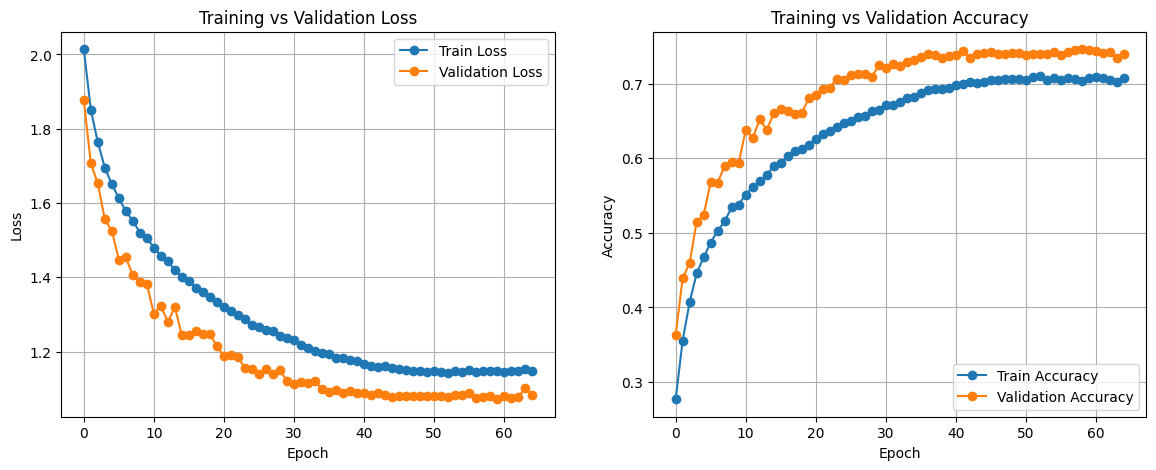

In [33]:
import matplotlib.pyplot as plt

# -------------------------
# Plot training & validation curves
# -------------------------
plt.figure(figsize=(14,5))

# Loss
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train Accuracy', marker='o')
plt.plot(val_accuracies, label='Validation Accuracy', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

plt.show()

In [34]:
import torch
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np

# -------------------------
# Evaluation function
# -------------------------
def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            preds = outputs.argmax(dim=1)

            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=[
        'airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck'
    ])

    return acc, cm, report

# -------------------------
# Evaluate ViT
# -------------------------
vit_acc, vit_cm, vit_report = evaluate_model(model, test_loader, device)

print(f"Test Accuracy: {vit_acc*100:.2f}%\n")
print("Confusion Matrix:\n", vit_cm)
print("\nClassification Report:\n", vit_report)

Test Accuracy: 74.10%

Confusion Matrix:
 [[823  46  25  10   5   4   6  14  39  28]
 [ 13 918   2   3   0   3   0   3  11  47]
 [ 90   5 678  42  48  43  47  32   8   7]
 [ 32  13  66 535  22 215  51  29  18  19]
 [ 24   6 106  45 607  40  38 121   8   5]
 [ 20   9  52 111  23 722  15  41   2   5]
 [ 21   8  39  56  26  41 799   5   3   2]
 [ 28  11  24  35  21  92   3 766   1  19]
 [103  49  17   7   2   7   3   1 790  21]
 [ 43 135   3  13   3   4   0  12  15 772]]

Classification Report:
               precision    recall  f1-score   support

    airplane       0.69      0.82      0.75      1000
  automobile       0.77      0.92      0.83      1000
        bird       0.67      0.68      0.67      1000
         cat       0.62      0.54      0.58      1000
        deer       0.80      0.61      0.69      1000
         dog       0.62      0.72      0.67      1000
        frog       0.83      0.80      0.81      1000
       horse       0.75      0.77      0.76      1000
        ship   

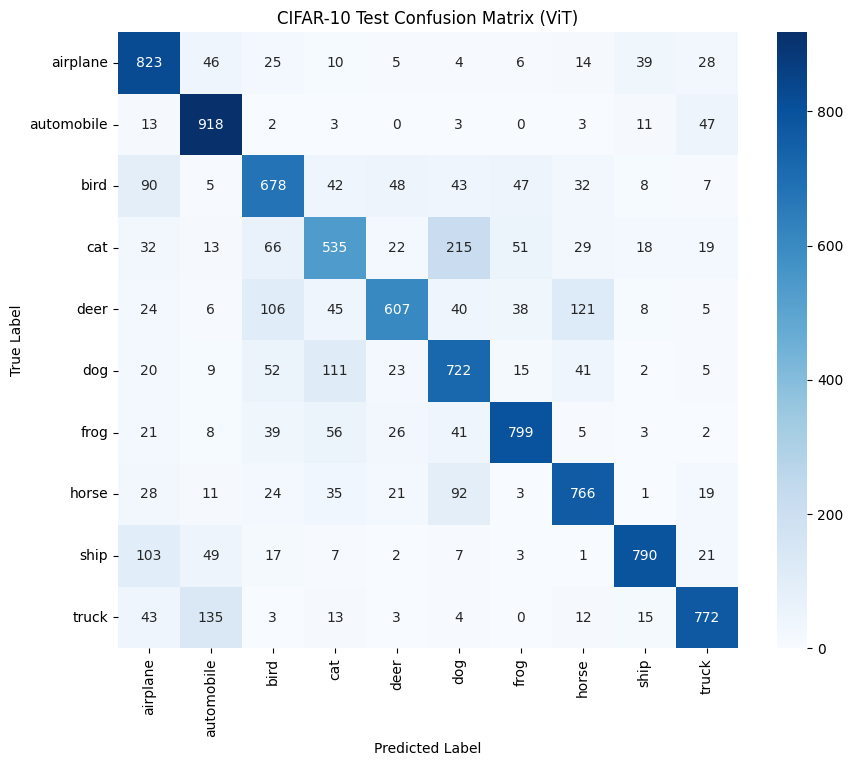

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# CIFAR-10 class names
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

cm = np.array([
    [823,  46,  25,  10,   5,   4,   6,  14,  39,  28],
    [ 13, 918,   2,   3,   0,   3,   0,   3,  11,  47],
    [ 90,   5, 678,  42,  48,  43,  47,  32,   8,   7],
    [ 32,  13,  66, 535,  22, 215,  51,  29,  18,  19],
    [ 24,   6, 106,  45, 607,  40,  38, 121,   8,   5],
    [ 20,   9,  52, 111,  23, 722,  15,  41,   2,   5],
    [ 21,   8,  39,  56,  26,  41, 799,   5,   3,   2],
    [ 28,  11,  24,  35,  21,  92,   3, 766,   1,  19],
    [103,  49,  17,   7,   2,   7,   3,   1, 790,  21],
    [ 43, 135,   3,  13,   3,   4,   0,  12,  15, 772]
])

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('CIFAR-10 Test Confusion Matrix (ViT)')
plt.show()

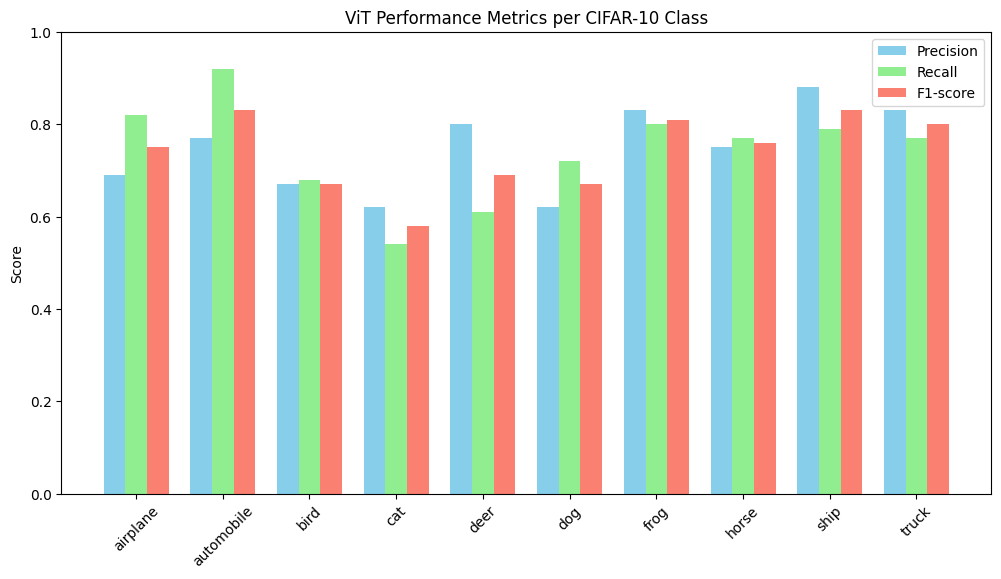

In [37]:
import matplotlib.pyplot as plt
import numpy as np

classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

precision = [0.69, 0.77, 0.67, 0.62, 0.80, 0.62, 0.83, 0.75, 0.88, 0.83]
recall    = [0.82, 0.92, 0.68, 0.54, 0.61, 0.72, 0.80, 0.77, 0.79, 0.77]
f1_score  = [0.75, 0.83, 0.67, 0.58, 0.69, 0.67, 0.81, 0.76, 0.83, 0.80]

x = np.arange(len(classes))  # class indices

plt.figure(figsize=(12,6))
plt.bar(x - 0.25, precision, width=0.25, label='Precision', color='skyblue')
plt.bar(x, recall, width=0.25, label='Recall', color='lightgreen')
plt.bar(x + 0.25, f1_score, width=0.25, label='F1-score', color='salmon')

plt.xticks(x, classes, rotation=45)
plt.ylim(0,1)
plt.ylabel('Score')
plt.title('ViT Performance Metrics per CIFAR-10 Class')
plt.legend()
plt.show()